In [1]:
import gseapy as gp
from lincs_gsnn.explain.infer_edge_weights import infer_edge_weights
import torch 
import pandas as pd 
from lincs_gsnn.explain.viz import annotate_edges, get_drug_edges, make_subgraph
from pypath.utils import mapping

from matplotlib import pyplot as plt 
import numpy as np 

from lincs_gsnn.models.ODEFunc import ODEFunc

from torchdiffeq import odeint

from scipy.stats import hypergeom
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader

from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.GSNNExplainer import GSNNExplainer

import seaborn as sbn 

%load_ext autoreload
%autoreload 2

In [2]:
root1 = '../../workflow_outputs/lincs-gsnn'
root2 = '../../workflow_outputs/lincs-traj'

data = torch.load(f'{root1}/default/bionetwork/bionetwork.pt', weights_only=False)
model = torch.load(f'{root1}/default/pretrain/pretrained_model.pt', weights_only=False).eval()
dxdt_scale = torch.load(f'{root1}/default/pretrain/dxdt_scale.pt', weights_only=False).item()
x_names = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/gene_names.csv')['gene_names'].values.astype(str)
dxdt_meta = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/dxdt_meta.csv')
x_meta = pd.read_csv(f'{root2}/runs/exp/default_v02/output/predict_grid/pred_meta.csv')

In [3]:
dxdt_dir = f'{root2}/runs/exp/default_v02/output/predict_grid/dxdt'

In [4]:
drugs = [x.split('__')[1] for x in data.node_names_dict['input'] if 'DRUG__' in x]
drugs = [drugs[-2]]

cond_res = [] 
for cell in dxdt_meta.cell_iname.unique():
    for drug in drugs: 
        print(f'{cell} - {drug}', end='\r')
        cond = dxdt_meta[lambda x: (x.cell_iname == cell) & (x.dose == 10.0) & (x.pert_id == drug)]
        dataset = DXDTDataset(cond, 
                              input_names=data.node_names_dict['input'], 
                              output_names=data.node_names_dict['output'], 
                              src_names=x_names, 
                              obs_dir=dxdt_dir, 
                              scale=dxdt_scale) 
        loader = DataLoader(dataset, batch_size=100, shuffle=False)
        X, _ = next(iter(loader))
        explainer = GSNNExplainer(model, data, hard=False, prior=3, iters=100, beta=1e-4, lr=1e-1, entropy=0)
        res = explainer.explain(X.cuda(), target='node')
        res = res.assign(cell=cell, drug=drug) 
        cond_res.append(res)

cond_res = pd.concat(cond_res)
cond_res.head()         

iter: 99 | loss: 0.3365 | mse: 0.1201 | r2: 0.984 | active nodes: 2105 / 4771 | entropy: 0.2851
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 1844 / 4771 (38.7%)
MSE (subset): 0.033369
R² (subset): 0.9957
Variance explained: 0.9957
Correlation: 0.9978
iter: 99 | loss: 0.2891 | mse: 0.0659 | r2: 0.993 | active nodes: 2174 / 4771 | entropy: 0.2827
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 1899 / 4771 (39.8%)
MSE (subset): 0.045808
R² (subset): 0.9952
Variance explained: 0.9952
Correlation: 0.9976
iter: 99 | loss: 0.3190 | mse: 0.0994 | r2: 0.988 | active nodes: 2139 / 4771 | entropy: 0.2878
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 1838 / 4771 (38.5%)
MSE (subset): 0.049411
R² (subset): 0.9940
Variance explained: 0.9941
Correlation: 0.9970
iter: 99 | loss: 0.4336 | mse: 0.2236 | r2: 0.974 | active nodes: 2032 / 4771 | entropy: 0.2880
POST-TRAINING EVALUATION (nodes > 0.5)
Selected nodes: 1767 / 4771 (37.0%)
MSE (subset): 0.065159
R² (subset): 0.9923
Var

,node,score,cell,drug
0,RNA__hsa-let-7i,0.964162,HME1,BRD-K51313569
1,RNA__PHKA1,0.147708,HME1,BRD-K51313569
2,PROTEIN__FOS,0.999681,HME1,BRD-K51313569
3,PROTEIN__GRK4,0.986872,HME1,BRD-K51313569
4,RNA__HMG20B,0.171600,HME1,BRD-K51313569


<Axes: >

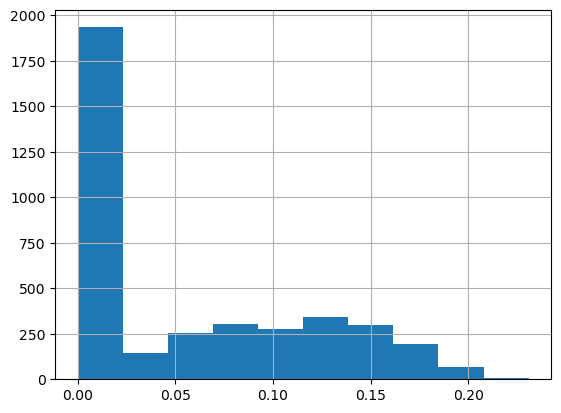

In [5]:
cond_res[['node', 'score']].groupby('node')\
    .var().score.hist() 

In [6]:
# select nodes that have high variance in importance scores  
hi_var_nodes = cond_res[['node', 'score']].groupby('node')\
    .var()[lambda x: x.score >= 0.2].index 
print('# nodes: ', len(hi_var_nodes))
cond_res_hi = cond_res[cond_res.node.isin(hi_var_nodes)]

# nodes:  17


In [7]:
# Need to zscore within node 
g = cond_res_hi.groupby('node')['score']
cond_res_hi = cond_res_hi.assign(z_score = (cond_res_hi['score'] - g.transform('mean')) / g.transform('std'))
cond_res_hi.head() 

,node,score,cell,drug,z_score
131,PROTEIN__TLR3,0.999028,HME1,BRD-K51313569,1.078571
417,RNA__PPOX,0.003060,HME1,BRD-K51313569,-1.005198
418,PROTEIN__ING1,0.996459,HME1,BRD-K51313569,0.927700
514,RNA__DHX29,0.010935,HME1,BRD-K51313569,-0.879577
882,PROTEIN__NR3C2,0.953171,HME1,BRD-K51313569,0.874675


In [8]:
cellinfo_linc = pd.read_csv('../../data/cellinfo_beta.txt', sep='\t')[['cell_iname', 'ccle_name']]
cellinfo_ccle = pd.read_csv('../../data/DepMap-2019q1-celllines_v2.csv')[['DepMap_ID', 'CCLE_Name']]
cellinfo_linc.rename(columns={'ccle_name': 'CCLE_Name'}, inplace=True) 
cellinfo = cellinfo_linc.merge(cellinfo_ccle, on='CCLE_Name', how='inner')

mut = pd.read_csv('../../data/OmicsSomaticMutations.csv')[['ModelID', 'VariantType', 'ProteinChange', 'HugoSymbol',  'UniprotID', 'LofGeneName', 'MolecularConsequence','Sift','Polyphen' , 'Rescue', 'RescueReason']]
mut = mut.merge(cellinfo, left_on='ModelID', right_on='DepMap_ID', how='inner')

mut = mut[['cell_iname', 'HugoSymbol', 'VariantType', 'Polyphen', 'Sift']]
mut.head() 

/tmp/ipykernel_21641/1619650792.py:6: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mut = pd.read_csv('../../data/OmicsSomaticMutations.csv')[['ModelID', 'VariantType', 'ProteinChange', 'HugoSymbol',  'UniprotID', 'LofGeneName', 'MolecularConsequence','Sift','Polyphen' , 'Rescue', 'RescueReason']]


,cell_iname,HugoSymbol,VariantType,Polyphen,Sift
0,22RV1,SAMD11,SNV,benign(0.055),deleterious_low_confidence(0.01)
1,GI1,SAMD11,SNV,possibly_damaging(0.615),tolerated_low_confidence(0.06)
2,HEC1A,SAMD11,SNV,benign(0.071),tolerated_low_confidence(0.16)
3,HEC265,SAMD11,insertion,NaN,NaN
4,MFE319,SAMD11,SNV,possibly_damaging(0.83),deleterious_low_confidence(0)


In [9]:
mut = mut.assign(polyphen_short = mut.Polyphen.str.split('(').str[0])
mut = mut.assign(sift_short = mut.Sift.str.split('(').str[0])
mut.sift_short = mut.sift_short.fillna('other')
mut.polyphen_short = mut.polyphen_short.fillna('other')
mut.head()


,cell_iname,HugoSymbol,VariantType,Polyphen,Sift,polyphen_short,sift_short
0,22RV1,SAMD11,SNV,benign(0.055),deleterious_low_confidence(0.01),benign,deleterious_low_confidence
1,GI1,SAMD11,SNV,possibly_damaging(0.615),tolerated_low_confidence(0.06),possibly_damaging,tolerated_low_confidence
2,HEC1A,SAMD11,SNV,benign(0.071),tolerated_low_confidence(0.16),benign,tolerated_low_confidence
3,HEC265,SAMD11,insertion,NaN,NaN,other,other
4,MFE319,SAMD11,SNV,possibly_damaging(0.83),deleterious_low_confidence(0),possibly_damaging,deleterious_low_confidence


In [10]:
druginfo = pd.read_csv('../../data/compoundinfo_beta.txt', sep='\t')
druginfo[lambda x: x.pert_id.isin(cond_res.drug.unique()) & (x.target == 'ERBB2')]

,pert_id,cmap_name,target,moa,canonical_smiles,inchi_key,compound_aliases


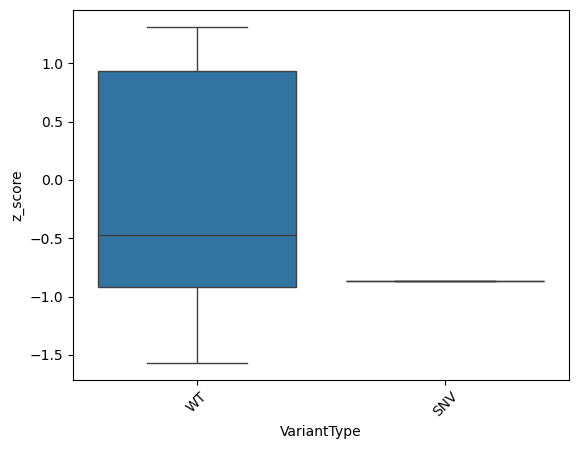

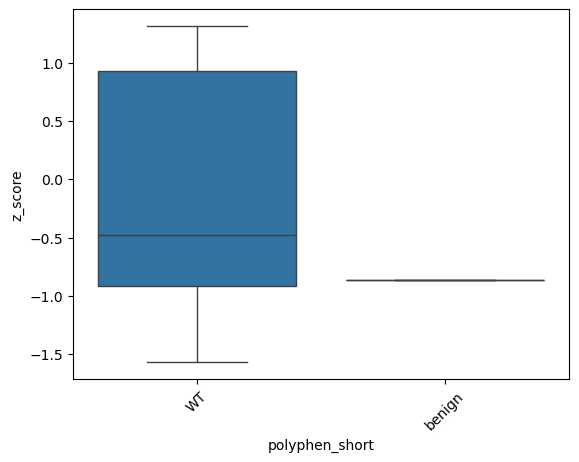

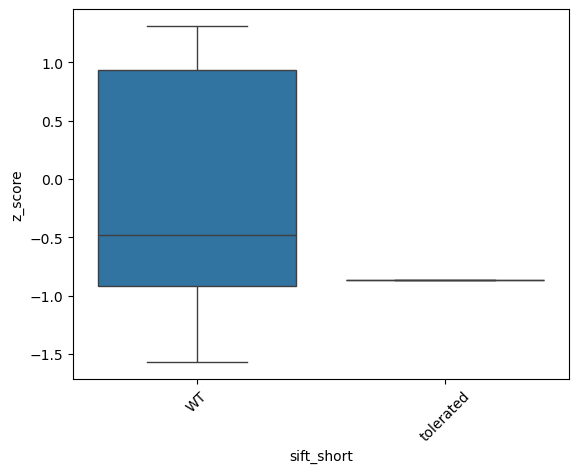

In [11]:
cond_res2 = cond_res_hi.assign(HugoSymbol=cond_res_hi.node.str.split('__').str[1]).rename(columns={'cell': 'cell_iname'})
cond_res2 = cond_res2.merge(mut, on=['HugoSymbol', 'cell_iname'], how='left') 
cond_res2 = cond_res2.assign(VariantType=cond_res2.VariantType.fillna('WT'))
cond_res2 = cond_res2.assign(polyphen_short=cond_res2.polyphen_short.fillna('WT'))
cond_res2 = cond_res2.assign(sift_short=cond_res2.sift_short.fillna('WT'))

plt.figure() 
sbn.boxplot(x='VariantType', y='z_score', data=cond_res2)
plt.xticks(rotation=45)
plt.show() 

plt.figure() 
sbn.boxplot(x='polyphen_short', y='z_score', data=cond_res2)
plt.xticks(rotation=45)
plt.show() 

plt.figure() 
sbn.boxplot(x='sift_short', y='z_score', data=cond_res2)
plt.xticks(rotation=45)
plt.show() 

In [12]:
agg_res = cond_res2.groupby('VariantType').agg({'z_score': 'mean'}).sort_values('z_score', ascending=False)
agg_res.head()

,z_score
VariantType,
WT,0.004662
SNV,-0.867127


In [13]:

null_res = [] 

nn = 250
for i in range(nn): 
    print(f'progress: {i}/{nn}', end='\r')
    mut_null = mut.assign(cell_iname=np.random.permutation(mut.cell_iname.values))

    cond_res3 = cond_res_hi.assign(HugoSymbol=cond_res_hi.node.str.split('__').str[1]).rename(columns={'cell': 'cell_iname'})
    cond_res3 = cond_res3.merge(mut_null, on=['HugoSymbol', 'cell_iname'], how='left') 
    cond_res3 = cond_res3.assign(VariantType=cond_res3.VariantType.fillna('WT'))

    agg = cond_res3.groupby('VariantType').agg({'z_score': 'mean'}).sort_values('z_score', ascending=False).T
    agg = agg.assign(iter=i)

    null_res.append(agg)

null_res = pd.concat(null_res)
null_res.head() 


VariantType,SNV,WT,deletion,iter,insertion
z_score,0.930490,-4.678611e-03,-0.034814,0,NaN
z_score,-0.810917,4.953814e-03,-0.050294,1,NaN
z_score,NaN,-1.434336e-08,NaN,2,NaN
z_score,0.706437,-9.331083e-03,1.019811,3,NaN
z_score,-1.080787,1.039417e-03,0.888492,4,NaN


In [14]:
for vt in agg_res.index: 
    pval = (null_res[vt].values <= agg_res.loc[vt].values[0]).mean()
    print(f'{vt}:\t {pval} \t[Null Hypothesis: True >= Observed]')

WT:	 0.724 	[Null Hypothesis: True >= Observed]
SNV:	 0.128 	[Null Hypothesis: True >= Observed]
